# Dense Noise

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [3]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [5]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [6]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['MouseCam_Right_V1_seq00_60Hz_10um_pixels.mp4',
 'MouseCam_Right_V1_seq00_60Hz_10um_pixels.npz',
 'MouseCam_Right_V1_seq00_60Hz_10um_pixels_mark.npz',
 'MouseCam_Right_V2-new_seq00_60Hz_10um_pixels.mp4',
 'MouseCam_Right_V2-new_seq00_60Hz_10um_pixels.npz',
 'MouseCam_Right_V2-new_seq00_60Hz_10um_pixels_mark.npz',
 'MouseCam_Right_V2_seq00_60Hz_10um_pixels.mp4',
 'MouseCam_Right_V2_seq00_60Hz_10um_pixels.npz',
 'MouseCam_Right_V2_seq00_60Hz_10um_pixels_mark.npz']

In [7]:
mcv2new_name = 'mcv2new'
mcv2new_file = 'MouseCam_Right_V2-new_seq00_60Hz_10um_pixels.npz'
mcv2new_mark_file = 'MouseCam_Right_V2-new_seq00_60Hz_10um_pixels_mark.npz'

mcv2_name = 'mcv2'
mcv2_file = 'MouseCam_Right_V2_seq00_60Hz_10um_pixels.npz'
mcv2_mark_file = 'MouseCam_Right_V2_seq00_60Hz_10um_pixels_mark.npz'

mcv1_name = 'mcv1'
mcv1_file = 'MouseCam_Right_V1_seq00_60Hz_10um_pixels.npz'
mcv1_mark_file = 'MouseCam_Right_V1_seq00_60Hz_10um_pixels_mark.npz'

In [8]:
# We downsample to reduce the size of the stimulus without losing any (!) information, since the frames are updated at 30 Hz.

target_freq = 30
source_freq = 60

t_downsample = int(source_freq/target_freq)  
t_downsample

2

## MouseCam V2-new

In [9]:
mcv2new_mark = np.load(os.path.join(qdspy_export_dir, mcv2new_mark_file))['data']
mcv2new_mark = np.append(mcv2new_mark[:-1] & (~mcv2new_mark[1:]), False)
i0 = np.argmax(mcv2new_mark > 0)
mcv2new_mark = mcv2new_mark[i0::t_downsample]
mcv2new_mark.shape, np.sum(mcv2new_mark)

((18479,), np.int64(123))

In [18]:
mcv2new = np.load(os.path.join(qdspy_export_dir, mcv2new_file))['data']
print(mcv2new.shape)
assert np.allclose(mcv2new[i0], mcv2new[np.any(mcv2new>0, axis=(1,2,3))][0])
mcv2new = mcv2new[i0::t_downsample, :, :]
mcv2new.shape

(37020, 120, 120, 3)


(18479, 120, 120, 3)

## MouseCam V2

In [19]:
mcv2_mark = np.load(os.path.join(qdspy_export_dir, mcv2_mark_file))['data']
mcv2_mark = np.append(mcv2_mark[:-1] & (~mcv2_mark[1:]), False)
i0 = np.argmax(mcv2_mark > 0)
mcv2_mark = mcv2_mark[i0::t_downsample]
mcv2_mark.shape, np.sum(mcv2_mark)

((18479,), np.int64(123))

In [20]:
mcv2 = np.load(os.path.join(qdspy_export_dir, mcv2_file))['data']
assert np.allclose(mcv2[i0], mcv2[np.any(mcv2>0, axis=(1,2,3))][0])
mcv2 = mcv2[i0::t_downsample, :, :]
mcv2.shape

(18479, 120, 120, 3)

## MouseCam V1

In [21]:
mcv1_mark = np.load(os.path.join(qdspy_export_dir, mcv1_mark_file))['data']
mcv1_mark = np.append(mcv1_mark[:-1] & (~mcv1_mark[1:]), False)
i0 = np.argmax(mcv1_mark > 0)
mcv1_mark = mcv1_mark[i0::t_downsample]
mcv1_mark.shape, np.sum(mcv1_mark)

((18479,), np.int64(123))

In [22]:
mcv1 = np.load(os.path.join(qdspy_export_dir, mcv1_file))['data']
assert np.allclose(mcv1[i0], mcv1[np.any(mcv1>0, axis=(1,2,3))][0])
# invert color channels from Setup3 movies to map to RGB
mcv1 = np.flip(mcv1, axis=3)
mcv1 = mcv1[i0::t_downsample, :, :]
mcv1.shape

(18479, 120, 120, 3)

## Compare

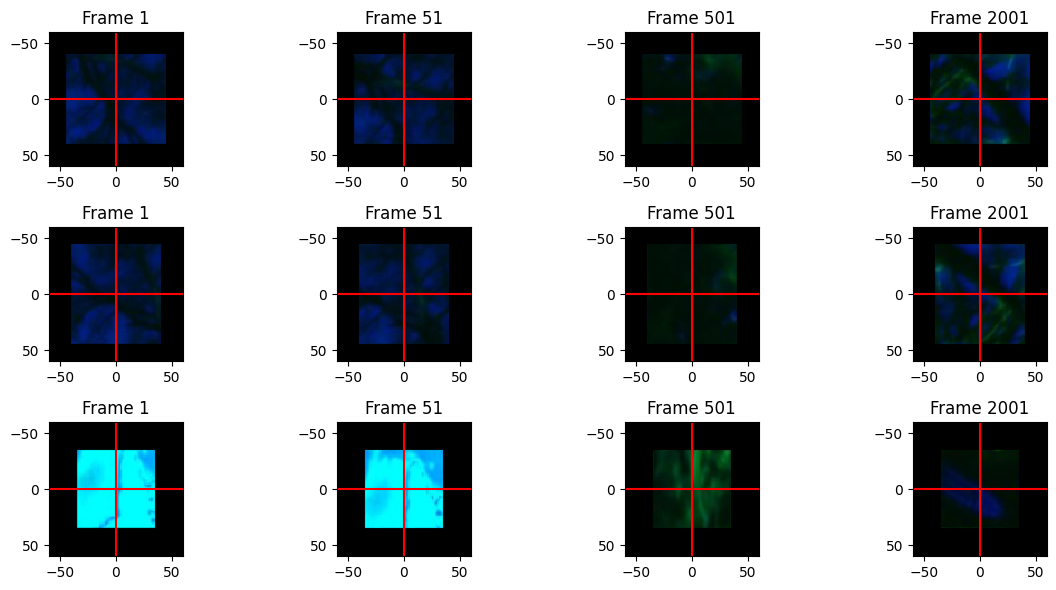

In [23]:
h, w = mcv2new.shape[1:3]
frames = [0, 50, 500, 2000]
fig, axs = plt.subplots(3, len(frames), figsize=(12, 6))

for j, frame in enumerate(frames):
    for i, stim in enumerate([mcv2new, mcv2, mcv1]):
        axs[i, j].imshow(stim[frame], vmin=0, vmax=255, interpolation='none', cmap='gray', extent=(-w/2, w/2, h/2, -h/2))
        axs[i, j].axhline(0, color='r')
        axs[i, j].axvline(0, color='r')
        axs[i, j].set(title=f'Frame {frame + 1}')

plt.tight_layout()
plt.show()

In [24]:
time_stim = np.arange(mcv2new.shape[0]) * t_downsample/60.

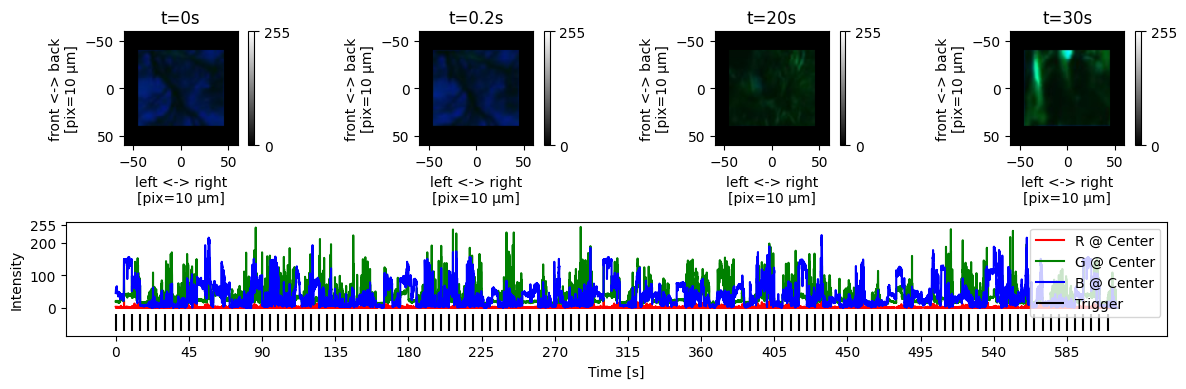

In [26]:
t_s_plot = (0, 1/5, 20, 30)

plot_stim(mcv2new, mcv2new_mark, time_stim, t_s_plot=t_s_plot);

In [34]:
mcv2new_setup1 = np.flip(np.rot90(mcv2new, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
mcv2_setup1 = np.flip(np.rot90(mcv2, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
#mcv1_setup1 = np.flip(np.rot90(mcv1, k=1, axes=(1, 2)), axis=1)[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]

#mcv2new_setup3 = np.rot90(mcv2new, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
#mcv2_setup3 = np.rot90(mcv2, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]
mcv1_setup3 = np.rot90(mcv1, k=1, axes=(1, 2))[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [35]:
stim_dict = {
    (mcv2new_name, '1'): mcv2new_setup1,
    (mcv2_name, '1'): mcv2_setup1,
    #(mcv1_name, '1'): mcv1_setup1,
    #(mcv2new_name, '3'): mcv2new_setup3,
    #(mcv2_name, '3'): mcv2_setup3,
    (mcv1_name, '3'): mcv1_setup3
}

Plotting mcv2new setup 1


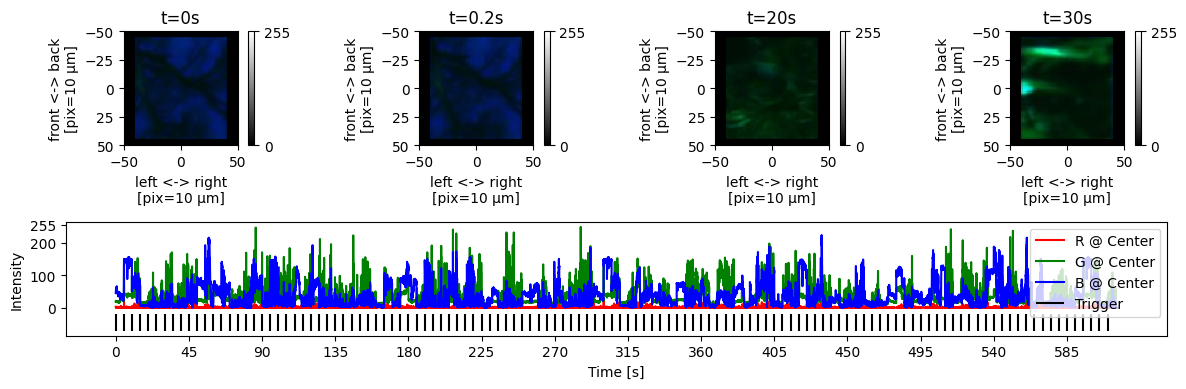

Plotting mcv2 setup 1


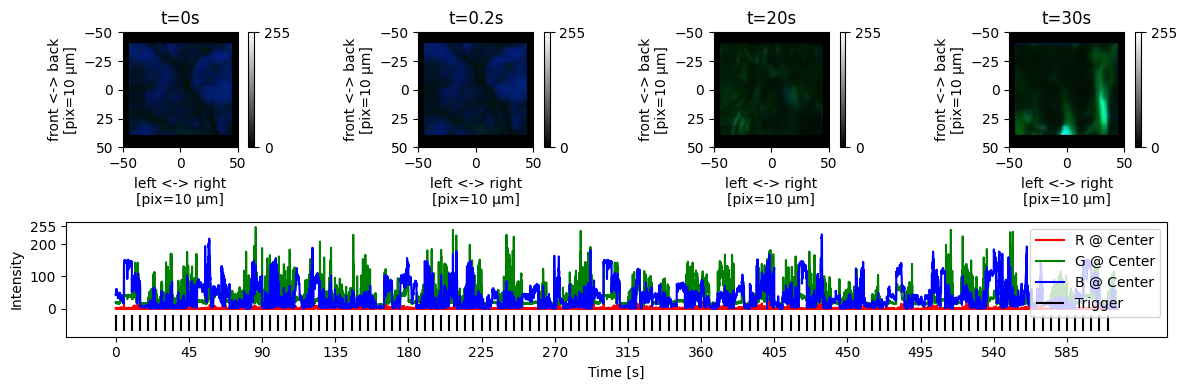

Plotting mcv1 setup 3


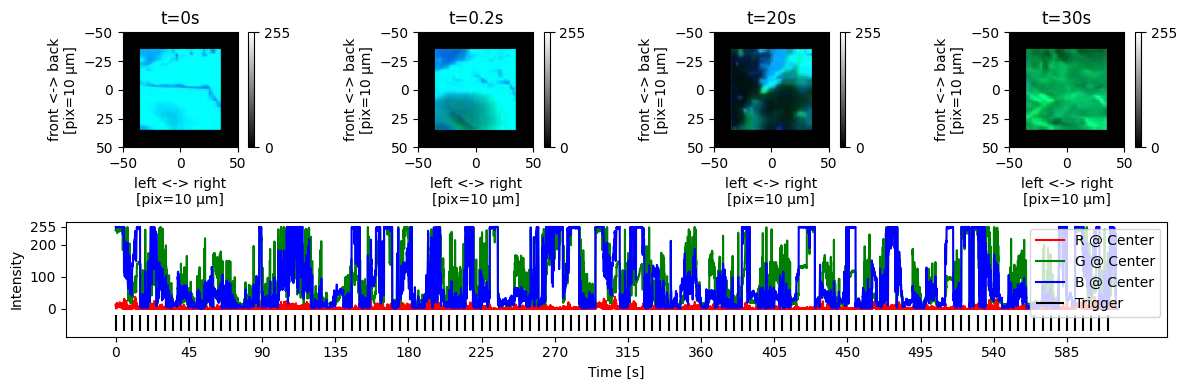

In [ ]:
for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name} setup {setup}')
    fig, axs = plot_stim(stim, mcv2new_mark, time_stim, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}_setup{setup}.pdf'), bbox_inches='tight')
    plt.show()

In [37]:
for (name, setup), stim in stim_dict.items():
    
    assert np.all(stim.astype(np.uint8) == stim)

    np.savez_compressed(
        os.path.join(out_dir, f'{name}_setup{setup}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        time=time_stim.astype(np.float32),
        trigger=mcv2new_mark,
    )